# Sales Forecasting 

## Internship Final Project 

### Imports 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import pmdarima
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

c:\Users\Sumit\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Task 1 -  Data Loading, Merging & Deep Exploration


### Loading Dataset

In [2]:
sales_df = pd.read_csv("train.csv")
games_df = pd.read_csv("vgsales.csv")

In [3]:
sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### Check shape 

In [4]:
sales_df.shape

(9800, 18)

### Check Data types

In [5]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

### Parse Date Columns 

In [6]:
# Convert Date Columns into datetime format (DD/MM/YYYY)


sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"],format="%d/%m/%Y")
sales_df["Ship Date"] = pd.to_datetime(sales_df["Ship Date"],format="%d/%m/%Y")

In [7]:
# Verify the updated data types

sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

### Time Feature Extraction 

In [8]:
# Extract time-based features from the Order Date
sales_df["Year"] = sales_df["Order Date"].dt.year
sales_df["Month"] = sales_df["Order Date"].dt.month
sales_df["Week Number"] = sales_df["Order Date"].dt.isocalendar().week
sales_df["Day of Week"] = sales_df["Order Date"].dt.day_name()
sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

In [9]:
sales_df['Order Date'].min(),sales_df['Order Date'].max()

(Timestamp('2015-01-03 00:00:00'), Timestamp('2018-12-30 00:00:00'))

### Season Feature

In [10]:
# Map each month to its corresponding season
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

sales_df["Season"] = sales_df["Month"].map(season_map)

### Data Quality Check

In [11]:
# check for missing values
sales_df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

### Observation 

Most of the columns do not contain any missing values. Only the 'Postal Code' column has 11 missing entries, while all other columns are complete.

In [12]:
# check for duplicate values
sales_df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found in the dataset, indicating that each transaction is unique. This helps ensure that the analysis and forecasting results are not affected by repeated entries.

In [13]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

### Observation

After converting the date columns, all features have appropriate data types. No additional data type issues were found in the dataset apart from the previously identified missing values in the Postal Code column.


In [14]:
sales_df['Order Date'].duplicated().sum()

np.int64(8570)

### Daily , weekly and Monthly Sales Aggregation

In [15]:
# Aggregate total sales for each day
daily_sales = (
    sales_df.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [16]:
daily_sales.shape

(1230, 2)

In [17]:
# Aggregate daily sales into weekly totals
weekly_sales = (
    daily_sales.set_index("Order Date")
    .resample("W")["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [18]:
# Aggregate daily sales into monthly totals
monthly_sales = (
    daily_sales.set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [19]:
sales_df['Category'].value_counts()

Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

### Revenue Analysis by Product Category

In [20]:
# Calculate the total revenue generated by each product category
category_revenue = sales_df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_revenue.round(2)

Category
Technology         827455.87
Furniture          728658.58
Office Supplies    705422.33
Name: Sales, dtype: float64

### Observation :

The Technology category generated the highest total revenue, contributing approximately $827,455.87 in sales. Furniture ranked second, while Office Supplies generated the lowest total revenue among the three categories.

### Revenue Visualization

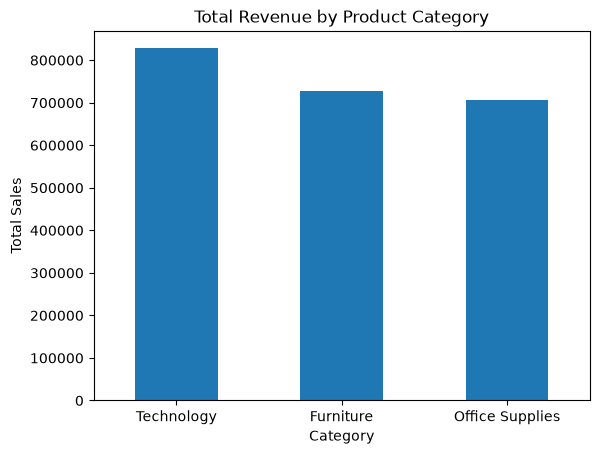

In [21]:
# Visualize total revenue by product category
category_revenue.plot(kind="bar")

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.savefig("charts/sales_by_product_category.png",dpi = 300,bbox_inches = "tight")
plt.show()

### Sales Growth By Region

In [22]:
# Calculate yearly sales for each region
region_sales = sales_df.groupby(["Year", "Region"])["Sales"].sum().unstack()

region_sales

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


### Sales Growth Visualization

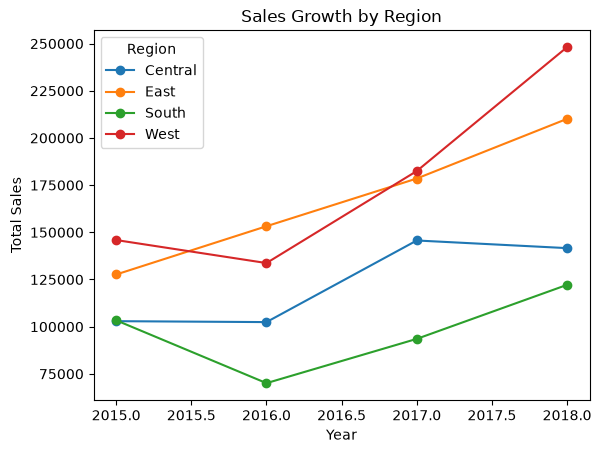

In [23]:
region_sales.plot(marker="o")

plt.title("Sales Growth by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.legend(title="Region")
plt.savefig("charts/sales_growth_by_region.png",dpi = 300,bbox_inches = "tight")
plt.show()

### Observation : 
The East region showed the most consistent sales growth over the four-year period, with sales increasing steadily each year. Although the West region achieved the highest overall sales by 2018, it experienced a decline between 2015 and 2016, making its growth less consistent than the East region.

### Shipping Time Analysis by Region

In [24]:
# Calculate the shipping time (in days) for each order
sales_df["Shipping Time"] = (
    sales_df["Ship Date"] - sales_df["Order Date"]
).dt.days

sales_df[["Order Date", "Ship Date", "Shipping Time"]].head()

,Order Date,Ship Date,Shipping Time
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [25]:
# Calculate the average shipping time for each region
shipping_time_by_region = (
    sales_df.groupby("Region")["Shipping Time"]
    .mean()
    .sort_values()
)

shipping_time_by_region.round(2)

Region
East       3.91
West       3.93
South      3.96
Central    4.07
Name: Shipping Time, dtype: float64

### Observation : 
The average shipping time is approximately 4 days across all regions. Although the Central region has the highest average shipping time (4.07 days) and the East region has the lowest (3.91 days), the differences are minimal, indicating a fairly consistent shipping process across regions.

### Monthly Sales Seasonality Analysis

In [26]:
sales_df.groupby(['Year',"Month"])["Sales"].sum().unstack()

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2015,14205.7070,4519.8920,55205.7970,27906.8550,23644.3030,34322.9356,33781.543,27117.5365,81623.5268,31453.3930,77907.6607,68167.0585
2016,18066.9576,11951.4110,32339.3184,34154.4685,29959.5305,23599.3740,28608.259,36818.3422,63133.6060,31011.7375,75249.3995,74543.6012
2017,18542.4910,22978.8150,51165.0590,38679.7670,56656.9080,39724.4860,38320.783,30542.2003,69193.3909,59583.0330,79066.4958,95739.1210
2018,43476.4740,19920.9974,58863.4128,35541.9101,43825.9822,48190.7277,44825.104,62837.8480,86152.8880,77448.1312,117938.1550,83030.3888


### Visualization

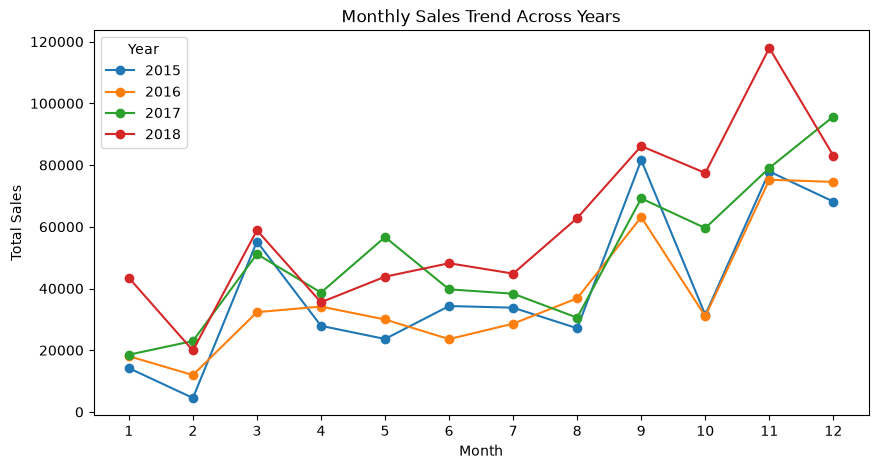

In [27]:
# Visualize monthly sales trends across different years
monthly_trend = sales_df.groupby(["Year", "Month"])["Sales"].sum().unstack()

monthly_trend.T.plot(figsize=(10, 5), marker="o")

plt.title("Monthly Sales Trend Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.savefig("charts/monthly_sales_trend.png",dpi = 300,bbox_inches = "tight")
plt.show()

### Observation : 
The sales data shows a clear seasonal pattern across all four years. Sales consistently increase during September, November, and December, with November recording the highest sales in most years. In contrast, the beginning of the year, particularly January and February, generally experiences lower sales. This indicates strong year-end seasonal demand.

##  Task 1 Summary

- Successfully loaded and explored the Superstore Sales dataset.
- Performed feature engineering by extracting time-based features.
- Checked data quality, including missing values, duplicates, and data types.
- Aggregated sales into daily, weekly, and monthly levels.
- Identified Technology as the highest revenue-generating category.
- Found that the East region showed the most consistent sales growth.
- Observed that average shipping time remained close to 4 days across all regions.
- Detected clear seasonality, with sales peaking during September, November, and December.

## Task 2 — Time Series Analysis & Decomposition

### Overall Monthly Sales Trend

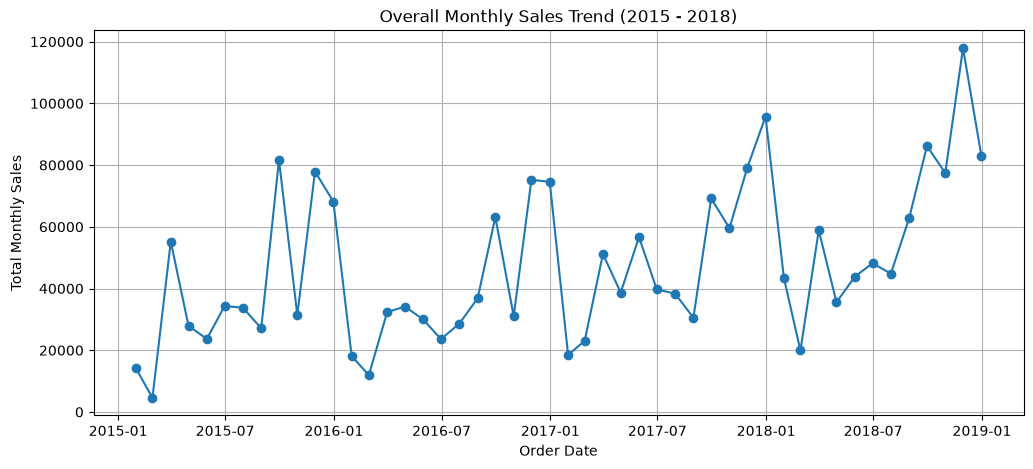

In [28]:
# Visualize the overall monthly sales trend
plt.figure(figsize=(12,5))

plt.plot(monthly_sales['Order Date'] , monthly_sales['Sales'],marker = "o")

plt.title("Overall Monthly Sales Trend (2015 - 2018)")
plt.xlabel("Order Date")
plt.ylabel("Total Monthly Sales")

plt.grid(True)
plt.savefig("charts/overall_monthly_sales_2015_2018.png",dpi = 300,bbox_inches = "tight")
plt.show()

### Time Series Decomposition

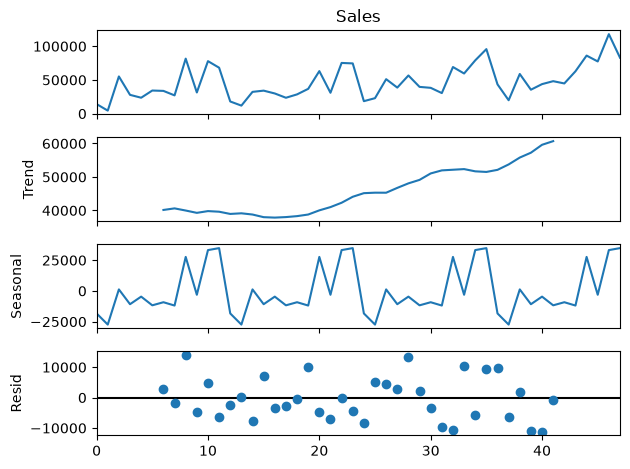

In [29]:
# Decompose the monthly sales time series into trends , seasonal and residual components
decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

decomposition.plot()
plt.savefig("charts/time_series_decomposition.png",dpi = 300,bbox_inches = "tight")
plt.show()

### Observation : 
1. The trend component shows a gradual upward movement over time, indicating that overall sales have increased during the four-year period.

2. The seasonal component displays a repeating pattern every year, suggesting that the sales data has strong seasonality.

3. The residual component appears to be randomly distributed around zero, indicating that most of the systematic trend and seasonal patterns have been successfully captured by the decomposition process.

4. A few months exhibit relatively high positive and negative residual values, showing occasional unexpected fluctuations in sales that cannot be explained by trend or seasonality alone.

### Stationarity Test (Augmented Dickey-Fuller Test)

In [30]:
# Perform the ADF test on the monthly sales series
adf_result = adfuller(monthly_sales["Sales"])

print(f"ADF Statistic : {adf_result[0]}")
print(f"P-value       : {adf_result[1]}")
print(f"Used Lags     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
P-value       : 0.00027791039276670623
Used Lags     : 0
Observations  : 47

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### Explanation :
The ADF test is used to check whether a time series is stationary.

If the p-value is less than 0.05, the null hypothesis is rejected, which indicates that the series is stationary.

If the p-value is greater than 0.05, the series is considered non-stationary.

### Observation : 
The p-value obtained from the ADF test is 0.00028, which is less than 0.05.

Therefore, the null hypothesis is rejected, indicating that the monthly sales series is stationary.

Since the series is already stationary, differencing is not required.

In [31]:
monthly_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  48 non-null     datetime64[us]
 1   Sales       48 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 900.0 bytes


## Task 3 — Sales Forecasting using 3 Different Models

### Model 1 — SARIMA (Statistical Model)


### Data Preparation for SARIMA

The monthly sales data was prepared for time series forecasting by setting the Order Date column as the index. The resulting time series contains 48 monthly observations from January 2015 to December 2018, making it suitable for SARIMA modeling.

In [32]:
# Create a copy of the monthly sales data for time series forecasting
ts_data = monthly_sales.copy()

# Set the Order Date as the index
ts_data.set_index("Order Date", inplace=True)


ts_data.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


### Parameter Selection using Auto ARIMA

In [33]:
# Automatically determine the best SARIMA parameters
auto_model = auto_arima(
    ts_data["Sales"],
    seasonal=True,
    m=12,                 # Monthly seasonality
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

# Display the selected model
print("Auto Model SUmmary : ",auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1079.923, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1096.560, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1076.500, Time=0.03 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1077.487, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1094.708, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1089.579, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1078.250, Time=0.07 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1078.452, Time=0.05 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1080.901, Time=0.04 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1079.864, Time=0.12 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1084.035, Time=0.03 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=1073.635, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1087.151, Time=0.02 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=1075.267, Time=0.08 sec
 ARIMA(2,1,0)(1,0,1

### Explanation : 
The SARIMA parameters were selected using the auto_arima() function from the pmdarima library. This function automatically evaluates multiple combinations of ARIMA and seasonal parameters and selects the model with the lowest Akaike Information Criterion (AIC), which indicates a better balance between model accuracy and complexity. The best model selected was SARIMA(2,1,0)(1,0,0,12) with an AIC score of 1071.915.

### SARIMA Model Traning

In [34]:
# Train the SARIMA model using the parameters selected by auto_arima
sarima_model = SARIMAX(
    ts_data["Sales"],
    order=(2, 1, 0),
    seasonal_order=(1, 0, 0, 12)
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(2, 1, 0)x(1, 0, 0, 12)   Log Likelihood                -531.958
Date:                            Wed, 08 Jul 2026   AIC                           1071.915
Time:                                    12:23:31   BIC                           1079.316
Sample:                                01-31-2015   HQIC                          1074.700
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6051      0.215     -2.816      0.005      -1.026      -0.184
ar.L2         -0.2364      0.209   

c:\Users\Sumit\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Sumit\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


### 3-Month Sales Forecast 

In [35]:
# Forecast the next 3 months
forecast = sarima_result.get_forecast(steps=3)

# Forecasted values
forecast_mean = forecast.predicted_mean

# Confidence intervals
forecast_ci = forecast.conf_int()

print("Forecasted Sales:")
print(forecast_mean)

print("\nConfidence Intervals:")
print(forecast_ci)

Forecasted Sales:
2019-01-31    71457.294746
2019-02-28    55170.675689
2019-03-31    75354.273328
Freq: ME, Name: predicted_mean, dtype: float64

Confidence Intervals:
             lower Sales    upper Sales
2019-01-31  26519.448461  116395.141031
2019-02-28   6856.399039  103484.952339
2019-03-31  21594.176479  129114.370178


### SARIMA Model Evaluation

In [36]:
# Predict on the training period
sarima_pred = sarima_result.predict(
    start=ts_data.index[1],
    end=ts_data.index[-1]
)

# Actual values
sarima_actual = ts_data.iloc[1:]

# Calculate metrics
sarima_mae = mean_absolute_error(sarima_actual, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(sarima_actual, sarima_pred))
sarima_mape =  np.mean(
    np.abs(
        (sarima_actual["Sales"].values - sarima_pred.values)
        / sarima_actual["Sales"].values
    )
) * 100



print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.2f}%")

MAE  : 14437.20
RMSE : 19386.18
MAPE : 42.11%


### Actual Vs Forecasted Sales

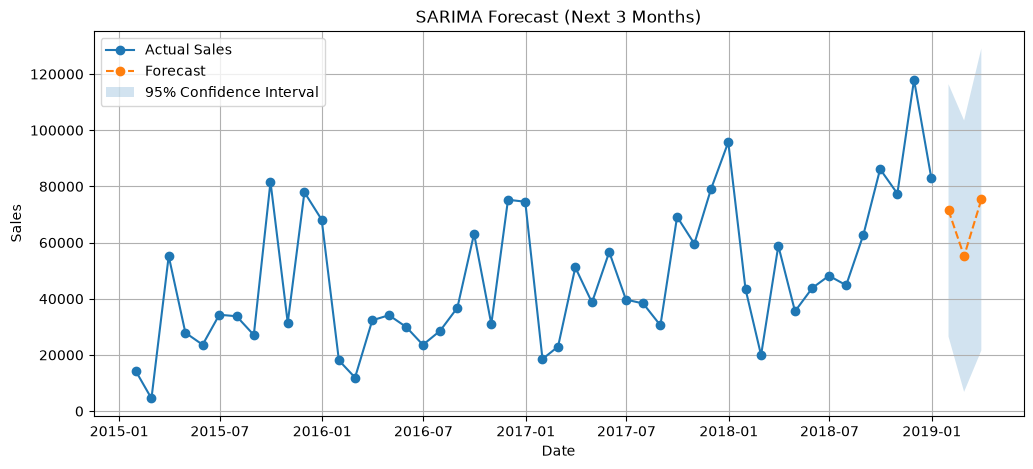

In [37]:
# Plot actual sales and forecasted sales
plt.figure(figsize=(12, 5))

# Historical sales
plt.plot(
    ts_data.index,
    ts_data["Sales"],
    label="Actual Sales",
    marker="o"
)

# Forecast
plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="Forecast",
    marker="o",
    linestyle="--"
)

# Confidence Interval
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast (Next 3 Months)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)
plt.savefig("charts/sarima_forecast.png",dpi = 300,bbox_inches = "tight")
plt.show()

### Observation : 
The SARIMA model predicts that sales will remain relatively stable over the next three months, with forecasted values of approximately 71,457, 55,171, and 75,354 respectively. The confidence intervals are fairly wide, indicating a degree of uncertainty in the predictions, which is expected due to the limited size of the historical dataset. Overall, the model captures the general sales trend and seasonal behavior, making it suitable as a baseline statistical forecasting model

## Model 2 — Facebook Prophet (Industry-Standard Forecasting Tool)

### Data Preparation

In [38]:
prophet_data = monthly_sales.copy()

prophet_data.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    },
    inplace=True
)

# Display
prophet_data.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Training the Prophet Model 

In [39]:
# Initialize the Prophet model
prophet_model = Prophet()

# Train model
prophet_model.fit(prophet_data)

12:23:31 - cmdstanpy - INFO - Chain [1] start processing
12:23:32 - cmdstanpy - INFO - Chain [1] done processing


### Generate 3-Month Sales Forecast

In [40]:


#  dataframe for the next 3 months
future = prophet_model.make_future_dataframe(periods=3, freq="ME")

# Generate predictions
prophet_forecast = prophet_model.predict(future)

# Display the last 3 forecasted months
prophet_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3)

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532203,33641.502373,51648.598613
49,2019-02-28,31248.159923,21814.937996,40636.269322
50,2019-03-31,81267.007773,72691.292014,90682.213050


### Propeht Model Evaluation

In [41]:
# Keep only the historical predictions
prophet_actual = prophet_data["y"]
prophet_pred = prophet_forecast.iloc[:len(prophet_data)]["yhat"]

# Calculate evaluation metrics
prophet_mae = mean_absolute_error(prophet_actual, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(prophet_actual, prophet_pred))
prophet_mape = np.mean(
    np.abs((prophet_actual.values - prophet_pred.values) / prophet_actual.values)
) * 100

print(f"MAE  : {prophet_mae:.2f}")
print(f"RMSE : {prophet_rmse:.2f}")
print(f"MAPE : {prophet_mape:.2f}%")

MAE  : 5770.42
RMSE : 7272.00
MAPE : 14.48%


### Prophet Forecast Visualization

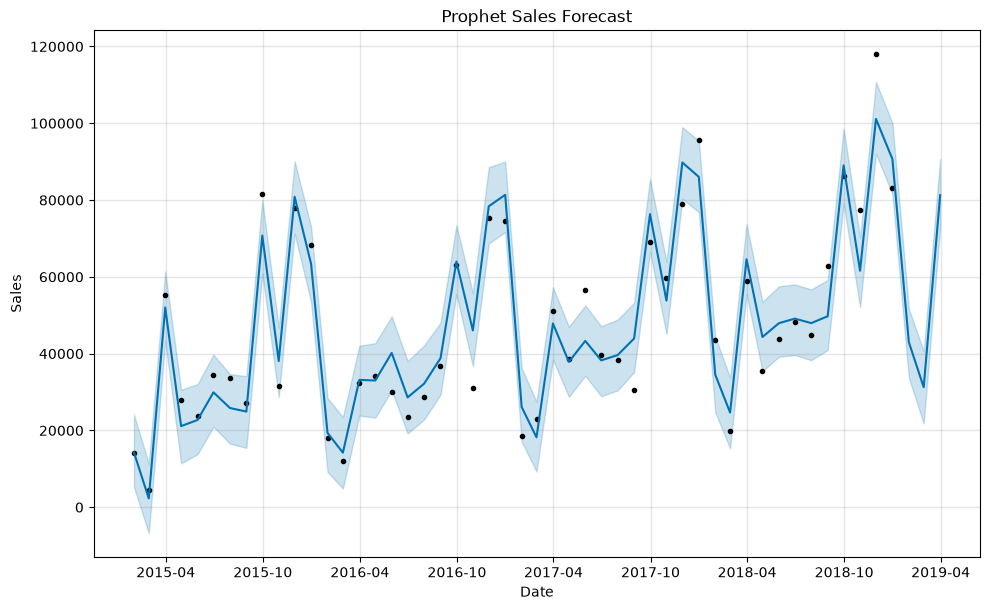

In [42]:
# Plot the forecast
fig1 = prophet_model.plot(prophet_forecast)

plt.title("Prophet Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.savefig("charts/prophet_sales_forecast.png",dpi = 300,bbox_inches = "tight")
plt.show()

### Trend and Seasonality Components

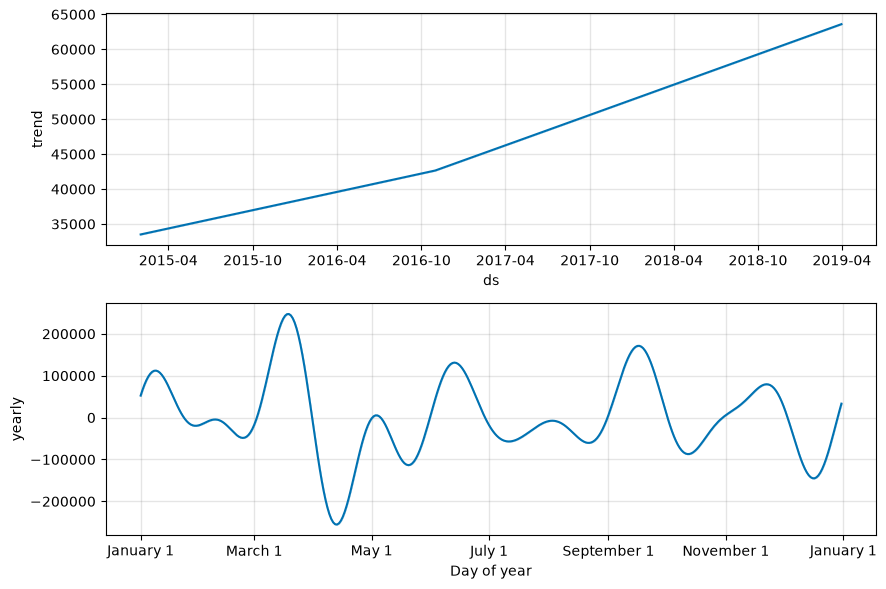

In [43]:
# Plot trend and seasonality components
fig2 = prophet_model.plot_components(prophet_forecast)
plt.savefig("charts/trend_vs_seasonality_compnonet.png",dpi = 300,bbox_inches = "tight")
plt.show()

### Observation : 
The Prophet model shows an overall upward sales trend over the four-year period, indicating gradual business growth. The yearly seasonality component suggests that sales fluctuate during different months of the year, confirming the presence of seasonal patterns. Since the dataset was aggregated at the monthly level, Prophet did not generate a weekly seasonality component because weekly patterns cannot be learned from monthly observations. The forecast predicts approximately 42,991, 31,248, and 81,267 sales for the next three months.

### Weekly Seasonality Note : 
Weekly seasonality was not generated because the dataset was aggregated to monthly sales before training the Prophet model. Weekly seasonality requires daily or weekly observations to identify recurring weekly patterns.

## Model 3 — XGBoost Regressor 

### Feature Engineerign

In [44]:
# Create a copy of the monthly sales data
xgb_data = monthly_sales.copy()

# Create lag features
xgb_data["Lag_1"] = xgb_data["Sales"].shift(1)
xgb_data["Lag_2"] = xgb_data["Sales"].shift(2)
xgb_data["Lag_3"] = xgb_data["Sales"].shift(3)

# Create 3-month rolling mean
xgb_data["Rolling_Mean_3"] = xgb_data["Sales"].rolling(window=3).mean()

# Extract calendar features
xgb_data["Month"] = xgb_data["Order Date"].dt.month
xgb_data["Quarter"] = xgb_data["Order Date"].dt.quarter

# Season feature
xgb_data["Season"] = xgb_data["Month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
})

# Display first rows
xgb_data.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-01-31,14205.707,NaN,NaN,NaN,NaN,1,1,Winter
1,2015-02-28,4519.892,14205.707,NaN,NaN,NaN,2,1,Winter
2,2015-03-31,55205.797,4519.892,14205.707,NaN,24643.798667,3,1,Spring
3,2015-04-30,27906.855,55205.797,4519.892,14205.707,29210.848000,4,2,Spring
4,2015-05-31,23644.303,27906.855,55205.797,4519.892,35585.651667,5,2,Spring


### Data Preparation

In [45]:
# Remove rows with missing values 
xgb_data = xgb_data.dropna().reset_index(drop=True)

# Check the dataset
xgb_data.head()

print("Shape:", xgb_data.shape)

Shape: (45, 9)


### Encoding Categorical Features

In [46]:
# Convert the Season column into numerical dummy variables
xgb_data = pd.get_dummies(
    xgb_data,
    columns=["Season"],
    drop_first=True
)

# Display the first few rows
xgb_data.head()

print("Columns:")
print(xgb_data.columns)

Columns:
Index(['Order Date', 'Sales', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3',
       'Month', 'Quarter', 'Season_Spring', 'Season_Summer', 'Season_Winter'],
      dtype='str')


### Feature Selection and Train-Test Split


In [47]:
# Features
X = xgb_data.drop(columns=["Order Date", "Sales"])

# Target
y = xgb_data["Sales"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (36, 9)
Testing Shape  : (9, 9)


### Trainig the XGBOOST Regressor 

In [48]:
# Initialize the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Model Prediction

In [49]:
# Predict sales for the test dataset
y_pred = xgb_model.predict(X_test)

# Display actual vs predicted values
prediction_df = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

prediction_df.head()

,Actual Sales,Predicted Sales
0,35541.9101,41741.976562
1,43825.9822,42012.585938
2,48190.7277,39361.777344
3,44825.1040,42697.855469
4,62837.8480,46730.320312


### Model Evaluation

In [50]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 8903.40
RMSE : 13351.83
MAPE : 12.51%


### Actual Vs Predicted Sales

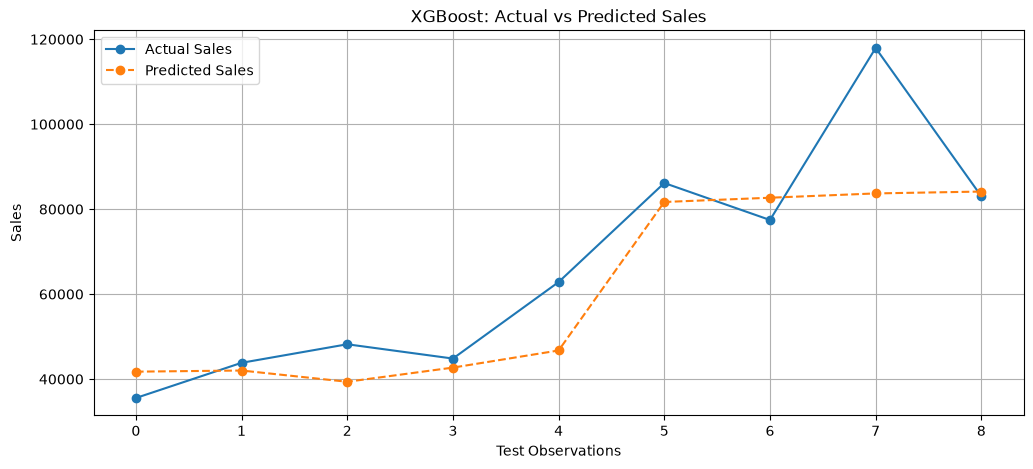

In [51]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label="Actual Sales",
    marker="o"
)

plt.plot(
    y_pred,
    label="Predicted Sales",
    marker="o",
    linestyle="--"
)

plt.title("XGBoost: Actual vs Predicted Sales")
plt.xlabel("Test Observations")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)
plt.savefig("charts/actual_vs_predicted_sales.png",dpi = 300,bbox_inches = "tight")
plt.show()

### Observation : 
The XGBoost model successfully captures the overall increasing trend in sales but smooths extreme fluctuations. It predicts the general direction of sales reasonably well, although it underestimates the highest sales peak. The model achieved a MAE of 8903.40, RMSE of 13351.83, and MAPE of 12.51%, indicating good forecasting performance on the test dataset.

### Forecasting the Next 3-Months Using XGBoost

In [52]:
future_predictions = []

# Last known sales values
last_sales = monthly_sales["Sales"].tolist()

# Predict next 3 months
for i in range(3):

    lag_1 = last_sales[-1]
    lag_2 = last_sales[-2]
    lag_3 = last_sales[-3]

    rolling_mean = np.mean([lag_1, lag_2, lag_3])

    month = (12 + i) % 12 + 1
    quarter = (month - 1) // 3 + 1

    season_spring = 1 if month in [3, 4, 5] else 0
    season_summer = 1 if month in [6, 7, 8] else 0
    season_winter = 1 if month in [12, 1, 2] else 0

    future_input = pd.DataFrame({
        "Lag_1": [lag_1],
        "Lag_2": [lag_2],
        "Lag_3": [lag_3],
        "Rolling_Mean_3": [rolling_mean],
        "Month": [month],
        "Quarter": [quarter],
        "Season_Spring": [season_spring],
        "Season_Summer": [season_summer],
        "Season_Winter": [season_winter]
    })

    prediction = xgb_model.predict(future_input)[0]

    future_predictions.append(prediction)
    last_sales.append(prediction)

# Display forecast
forecast_df = pd.DataFrame({
    "Month": ["2019-01", "2019-02", "2019-03"],
    "Forecasted Sales": future_predictions
})

forecast_df

,Month,Forecasted Sales
0,2019-01,52179.890625
1,2019-02,40521.664062
2,2019-03,61992.574219


### Model Comparisoon

In [53]:
comparison_df = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [
        round(sarima_mae, 2),
        round(prophet_mae, 2),
        round(mae, 2)
    ],
    "RMSE": [
        round(sarima_rmse, 2),
        round(prophet_rmse, 2),
        round(rmse, 2)
    ],
    "MAPE": [
        round(sarima_mape, 2),
        round(prophet_mape, 2),
        round(mape, 2)
    ],
    "Forecast Month 1": [
        round(forecast_mean.iloc[0], 2),
        round(prophet_forecast["yhat"].iloc[-3], 2),
        round(future_predictions[0], 2)
    ],
    "Forecast Month 2": [
        round(forecast_mean.iloc[1], 2),
        round(prophet_forecast["yhat"].iloc[-2], 2),
        round(future_predictions[1], 2)
    ],
    "Forecast Month 3": [
        round(forecast_mean.iloc[2], 2),
        round(prophet_forecast["yhat"].iloc[-1], 2),
        round(future_predictions[2], 2)
    ]
})

comparison_df

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,14437.20,19386.18,42.11,71457.290000,55170.680000,75354.270000
1,Prophet,5770.42,7272.00,14.48,42990.530000,31248.160000,81267.010000
2,XGBoost,8903.40,13351.83,12.51,52179.890625,40521.660156,61992.578125


### Best Model Recommendation : 
Based on the evaluation metrics, Prophet is recommended for production use because it achieved the lowest MAE (5770.42) and RMSE (7272.00), indicating the best overall forecasting accuracy. Although XGBoost achieved a slightly lower MAPE (12.51%), Prophet demonstrated more consistent performance across the major evaluation metrics and is therefore recommended as the final forecasting model.

## Task 4 — Product Category & Region Level Forecasting


### Furniture Sales Forecast using Prophet

In [54]:
# Filter only Furniture category
furniture_df = sales_df[sales_df["Category"] == "Furniture"]

# Convert Order Date to datetime
furniture_df["Order Date"] = pd.to_datetime(furniture_df["Order Date"])

# Create monthly sales
furniture_monthly = (
    furniture_df
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
    .reset_index()
)

# Prophet format
furniture_monthly = furniture_monthly.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

furniture_monthly.head()

,ds,y
0,2015-01-31,6217.277
1,2015-02-28,1839.658
2,2015-03-31,14243.368
3,2015-04-30,7944.837
4,2015-05-31,6912.787


### Train Prophet Model

In [55]:
# Create Prophet model
furniture_model = Prophet()

# Train
furniture_model.fit(furniture_monthly)

12:23:33 - cmdstanpy - INFO - Chain [1] start processing
12:23:34 - cmdstanpy - INFO - Chain [1] done processing


### Forecast Next 3 Months

In [56]:
# Creating dataframe
furniture_future = furniture_model.make_future_dataframe(periods=3, freq="ME")

# Predict
furniture_forecast = furniture_model.predict(furniture_future)

# Display future predictions
furniture_forecast[["ds", "yhat"]].tail(3)

,ds,yhat
48,2019-01-31,12691.392668
49,2019-02-28,6772.162417
50,2019-03-31,17201.015648


### Forecast Function using Prophet

In [57]:
def forecast_segment(df, column_name, value):
    # Filter the data
    segment_df = df[df[column_name] == value].copy()

    # Convert date
    segment_df["Order Date"] = pd.to_datetime(segment_df["Order Date"])

    # Monthly sales
    monthly_sales = (
        segment_df
        .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
        .reset_index()
    )

    # Prophet format
    monthly_sales = monthly_sales.rename(
        columns={
            "Order Date": "ds",
            "Sales": "y"
        }
    )

    # Train Prophet
    model = Prophet()
    model.fit(monthly_sales)

    # Forecast
    future = model.make_future_dataframe(periods=3, freq="ME")
    forecast = model.predict(future)

    return forecast

In [58]:
furniture_forecast = forecast_segment(
    sales_df,
    "Category",
    "Furniture"
)

furniture_forecast[["ds", "yhat"]].tail(3)

12:23:34 - cmdstanpy - INFO - Chain [1] start processing
12:23:34 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
48,2019-01-31,12691.392668
49,2019-02-28,6772.162417
50,2019-03-31,17201.015648


In [59]:
technology_forecast = forecast_segment(
    sales_df,
    "Category",
    "Technology"
)

office_forecast = forecast_segment(
    sales_df,
    "Category",
    "Office Supplies"
)

west_forecast = forecast_segment(
    sales_df,
    "Region",
    "West"
)

east_forecast = forecast_segment(
    sales_df,
    "Region",
    "East"
)

12:23:34 - cmdstanpy - INFO - Chain [1] start processing
12:23:34 - cmdstanpy - INFO - Chain [1] done processing
12:23:34 - cmdstanpy - INFO - Chain [1] start processing
12:23:35 - cmdstanpy - INFO - Chain [1] done processing
12:23:35 - cmdstanpy - INFO - Chain [1] start processing
12:23:35 - cmdstanpy - INFO - Chain [1] done processing
12:23:35 - cmdstanpy - INFO - Chain [1] start processing
12:23:35 - cmdstanpy - INFO - Chain [1] done processing


In [60]:
print("Furniture")
print(furniture_forecast[["ds", "yhat"]].tail(3))

print("\nTechnology")
print(technology_forecast[["ds", "yhat"]].tail(3))

print("\nOffice Supplies")
print(office_forecast[["ds", "yhat"]].tail(3))

print("\nWest")
print(west_forecast[["ds", "yhat"]].tail(3))

print("\nEast")
print(east_forecast[["ds", "yhat"]].tail(3))

Furniture
           ds          yhat
48 2019-01-31  12691.392668
49 2019-02-28   6772.162417
50 2019-03-31  17201.015648

Technology
           ds          yhat
48 2019-01-31  14033.343185
49 2019-02-28  10437.986784
50 2019-03-31  42639.488041

Office Supplies
           ds          yhat
48 2019-01-31  14646.724651
49 2019-02-28  12434.656284
50 2019-03-31  19698.155527

West
           ds          yhat
48 2019-01-31  14048.800881
49 2019-02-28  11840.373160
50 2019-03-31  25805.336395

East
           ds          yhat
48 2019-01-31   9713.411357
49 2019-02-28   8120.218592
50 2019-03-31  15639.421337


### Comparison of Forecast Across Catgories and Regions

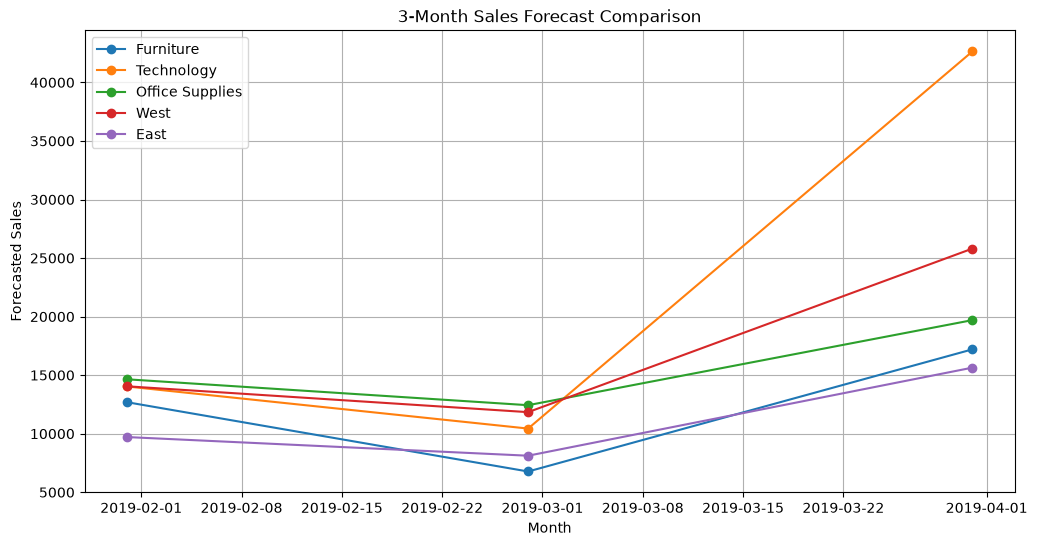

In [61]:
plt.figure(figsize=(12,6))

plt.plot(
    furniture_forecast["ds"].tail(3),
    furniture_forecast["yhat"].tail(3),
    marker="o",
    label="Furniture"
)

plt.plot(
    technology_forecast["ds"].tail(3),
    technology_forecast["yhat"].tail(3),
    marker="o",
    label="Technology"
)

plt.plot(
    office_forecast["ds"].tail(3),
    office_forecast["yhat"].tail(3),
    marker="o",
    label="Office Supplies"
)

plt.plot(
    west_forecast["ds"].tail(3),
    west_forecast["yhat"].tail(3),
    marker="o",
    label="West"
)

plt.plot(
    east_forecast["ds"].tail(3),
    east_forecast["yhat"].tail(3),
    marker="o",
    label="East"
)

plt.title("3-Month Sales Forecast Comparison")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")
plt.legend()

plt.grid(True)
plt.savefig("charts/3_months_sales_forecast_comparison.png",dpi = 300,bbox_inches = "tight")
plt.show()

### Observation :
According to the Prophet forecasting model, the Technology category is expected to show the strongest upcoming growth among all categories and regions. Its forecast increases sharply by March 2019, reaching approximately 42,639, which is significantly higher than the forecasts for Furniture, Office Supplies, West, and East. This indicates that Technology is likely to contribute the highest future sales during the forecast period.

## Task 5 — Anomaly Detection in Sales Data


### Weekly Sales Preparation

In [62]:
# Convert Order Date to datetime
sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"])

# Aggregate weekly sales
weekly_sales = (
    sales_df
    .groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


### Isolation Forest For Anomaly Detection

In [63]:
# Create the model
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Fit the model
weekly_sales["Anomaly"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


### Weekly Sales Anomalies using Isolation Forest 

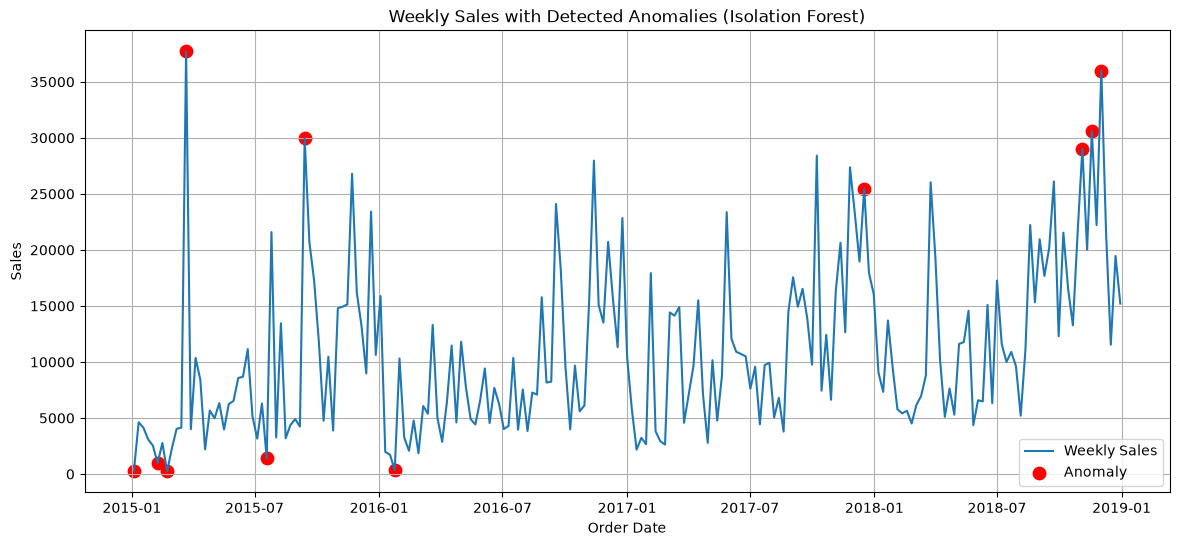

In [64]:
plt.figure(figsize=(14, 6))

# Plot normal sales
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

# Plot anomalies
anomalies = weekly_sales[weekly_sales["Anomaly"] == -1]

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    marker="o",
    s=80,
    label="Anomaly"
)

plt.title("Weekly Sales with Detected Anomalies (Isolation Forest)")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)
plt.savefig("charts/isolation_forest_anomaly_detection.png",dpi = 300,bbox_inches = "tight")
plt.show()

### Detected Anomalies 

In [65]:
anomalies

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


### Observation : 
The Isolation Forest model successfully detected both unusually high and unusually low weekly sales. Low-sales anomalies may indicate periods of reduced customer activity, inventory shortages, or holiday closures. High-sales anomalies are likely associated with promotional events, festive shopping seasons, or special sales campaigns such as Black Friday and Christmas. These detected anomalies represent periods that significantly deviate from normal sales behavior.

### Z-Score Based Anomaly Detection

In [66]:
# Calculate rolling mean and rolling standard deviation
weekly_sales["Rolling_Mean"] = weekly_sales["Sales"].rolling(
    window=12,
    min_periods=1
).mean()

weekly_sales["Rolling_STD"] = weekly_sales["Sales"].rolling(
    window=12,
    min_periods=1
).std()

weekly_sales.head()

,Order Date,Sales,Anomaly,Rolling_Mean,Rolling_STD
0,2015-01-04,304.508,-1,304.508000,NaN
1,2015-01-11,4619.108,1,2461.808000,3050.882918
2,2015-01-18,4130.533,1,3018.049667,2362.659024
3,2015-01-25,3092.544,1,3036.673250,1929.462566
4,2015-02-01,2527.914,1,2934.921400,1686.382679


In [67]:
# calculating z-score
weekly_sales["Z_Score"] = (
    (weekly_sales["Sales"] - weekly_sales["Rolling_Mean"])
    / weekly_sales["Rolling_STD"]
)

weekly_sales.head()

,Order Date,Sales,Anomaly,Rolling_Mean,Rolling_STD,Z_Score
0,2015-01-04,304.508,-1,304.508000,NaN,NaN
1,2015-01-11,4619.108,1,2461.808000,3050.882918,0.707107
2,2015-01-18,4130.533,1,3018.049667,2362.659024,0.470861
3,2015-01-25,3092.544,1,3036.673250,1929.462566,0.028957
4,2015-02-01,2527.914,1,2934.921400,1686.382679,-0.241349


In [68]:
weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z_Score"].abs() > 2
)

weekly_sales.head()

,Order Date,Sales,Anomaly,Rolling_Mean,Rolling_STD,Z_Score,Z_Anomaly
0,2015-01-04,304.508,-1,304.508000,NaN,NaN,False
1,2015-01-11,4619.108,1,2461.808000,3050.882918,0.707107,False
2,2015-01-18,4130.533,1,3018.049667,2362.659024,0.470861,False
3,2015-01-25,3092.544,1,3036.673250,1929.462566,0.028957,False
4,2015-02-01,2527.914,1,2934.921400,1686.382679,-0.241349,False


In [69]:
# Display the anomaly
z_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"] == True
]

z_anomalies

,Order Date,Sales,Anomaly,Rolling_Mean,Rolling_STD,Z_Score,Z_Anomaly
11,2015-03-22,37703.6650,-1,5566.895417,10231.056755,3.141100,True
29,2015-07-26,21590.0800,1,7419.081467,5168.448274,2.741828,True
36,2015-09-13,29959.1370,-1,8410.900625,8818.880514,2.443421,True
86,2016-08-28,15773.4780,1,6884.831017,3452.051770,2.574888,True
89,2016-09-18,24095.9600,1,8719.944100,5907.368621,2.602854,True
125,2017-05-28,23367.6620,1,10240.090833,5850.213912,2.243947,True
139,2017-09-03,17558.9918,1,9177.002108,4046.233428,2.071554,True
144,2017-10-08,28412.0980,1,12562.475767,6691.304454,2.368689,True
168,2018-03-25,26029.9040,1,9070.914033,5892.648755,2.877991,True
189,2018-08-19,22222.5540,1,11033.270092,5050.794376,2.215351,True


In [70]:
weekly_sales['Z_Anomaly'].value_counts()

Z_Anomaly
False    199
True      10
Name: count, dtype: int64

### Weekly Sales Anomalies using Z-Score

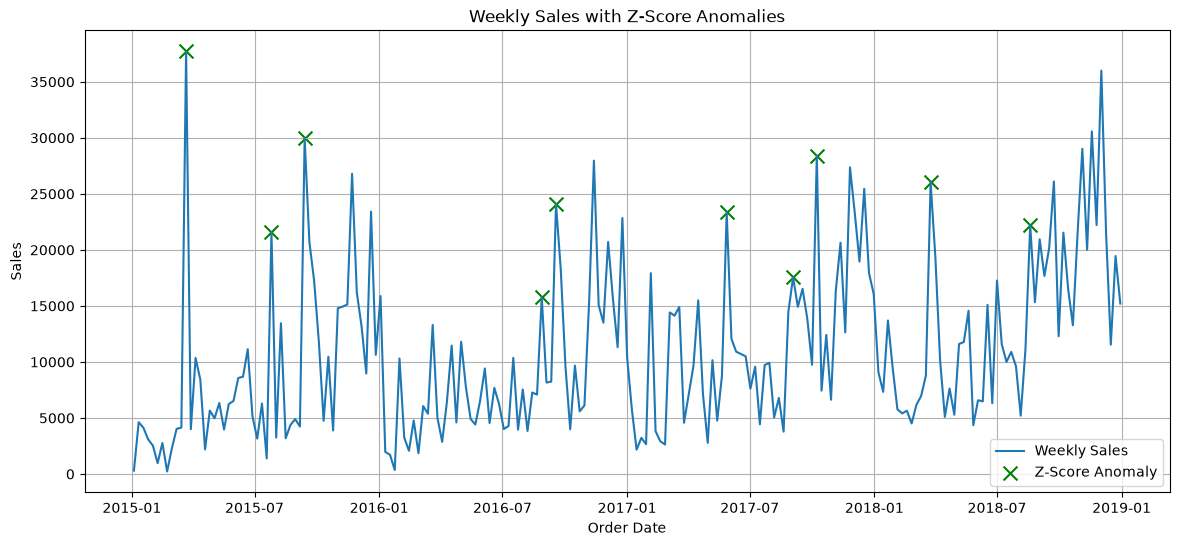

In [71]:
plt.figure(figsize=(14,6))

# Weekly sales
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

# Z-score anomalies
plt.scatter(
    z_anomalies["Order Date"],
    z_anomalies["Sales"],
    color="green",
    marker="x",
    s=100,
    label="Z-Score Anomaly"
)

plt.title("Weekly Sales with Z-Score Anomalies")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)
plt.savefig("charts/z_score_anomaly_detection.png",dpi = 300,bbox_inches = "tight")
plt.show()

### Observation : 
Comparison of Isolation Forest and Z-Score Methods

The two methods identified some of the same high-sales anomalies, but they did not detect exactly the same weeks. Isolation Forest detected both unusually high and unusually low sales weeks, whereas the Z-Score method mainly identified weeks with exceptionally high sales that were more than two standard deviations above the rolling mean. This difference indicates that Isolation Forest is more flexible and can identify different types of unusual patterns, while the Z-Score method relies purely on statistical deviation from the rolling mean. Therefore, using both methods together provides a more comprehensive understanding of anomalous sales behavior.

## Task 6 — Product Demand Segmentation using Clustering

In [72]:
# Create a copy
cluster_df = sales_df.copy()

# Extract year and month
cluster_df["Year"] = cluster_df["Order Date"].dt.year
cluster_df["Month"] = cluster_df["Order Date"].dt.month

cluster_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Week Number,Day of Week,Quarter,Season,Shipping Time
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Autumn,7


## Feature Engineering for Product Demand Segmentation
### Total Sales Volume

In [73]:
# Total Sales Volume for each Sub-Category
total_sales = (
    cluster_df
    .groupby("Sub-Category")["Sales"]
    .sum()
    .reset_index(name="Total_Sales")
)

total_sales

,Sub-Category,Total_Sales
0,Accessories,164186.7000
1,Appliances,104618.4030
2,Art,26705.4100
3,Binders,200028.7850
4,Bookcases,113813.1987
5,Chairs,322822.7310
6,Copiers,146248.0940
7,Envelopes,16128.0460
8,Fasteners,3001.9600
9,Furnishings,89212.0180


### Sales Growth Rate (Year-over-Year)

In [74]:
# Total yearly sales for each sub-category
yearly_sales = (
    cluster_df
    .groupby(["Sub-Category", "Year"])["Sales"]
    .sum()
    .reset_index()
)

yearly_sales.head()

,Sub-Category,Year,Sales
0,Accessories,2015,23766.396
1,Accessories,2016,40443.970
2,Accessories,2017,41735.364
3,Accessories,2018,58240.970
4,Appliances,2015,15160.715


In [75]:
# Calculate Year-over-Year Growth Rate
yearly_sales["Growth_Rate"] = (
    yearly_sales
    .groupby("Sub-Category")["Sales"]
    .pct_change()
)

yearly_sales.head(10)

,Sub-Category,Year,Sales,Growth_Rate
0,Accessories,2015,23766.396,NaN
1,Accessories,2016,40443.970,0.701729
2,Accessories,2017,41735.364,0.031930
3,Accessories,2018,58240.970,0.395482
4,Appliances,2015,15160.715,NaN
5,Appliances,2016,23228.179,0.532130
6,Appliances,2017,26016.787,0.120053
7,Appliances,2018,40212.722,0.545645
8,Art,2015,5897.534,NaN
9,Art,2016,6091.636,0.032912


In [76]:
# Average growth rate for each Sub-Category
growth_rate = (
    yearly_sales
    .groupby("Sub-Category")["Growth_Rate"]
    .mean()
    .reset_index(name="Sales_Growth_Rate")
)

growth_rate

,Sub-Category,Sales_Growth_Rate
0,Accessories,0.376381
1,Appliances,0.399276
2,Art,0.166056
3,Binders,0.218736
4,Bookcases,0.238065
5,Chairs,0.071358
6,Copiers,0.846718
7,Envelopes,-0.027666
8,Fasteners,0.157034
9,Furnishings,0.287889


### Sales Volatility (Monthly Standard Deviation)

In [77]:
# Monthly sales for each sub-category
monthly_sales = (
    cluster_df
    .groupby(["Sub-Category", "Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Sub-Category,Year,Month,Sales
0,Accessories,2015,1,827.890
1,Accessories,2015,2,1120.990
2,Accessories,2015,3,957.734
3,Accessories,2015,4,2323.700
4,Accessories,2015,5,695.490


In [78]:
# Sales volatility (standard deviation of monthly sales)
volatility = (
    monthly_sales
    .groupby("Sub-Category")["Sales"]
    .std()
    .reset_index(name="Sales_Volatility")
)

volatility

,Sub-Category,Sales_Volatility
0,Accessories,2579.994809
1,Appliances,1821.621539
2,Art,330.488343
3,Binders,3848.223648
4,Bookcases,2220.405080
5,Chairs,4407.232960
6,Copiers,5500.774391
7,Envelopes,228.218688
8,Fasteners,48.742229
9,Furnishings,1360.017867


### Average Order Value

In [79]:
# Average Order Value for each Sub-Category
avg_order_value = (
    cluster_df
    .groupby("Sub-Category")["Sales"]
    .mean()
    .reset_index(name="Average_Order_Value")
)

avg_order_value

,Sub-Category,Average_Order_Value
0,Accessories,217.178175
1,Appliances,227.926804
2,Art,34.019631
3,Binders,134.067550
4,Bookcases,503.598224
5,Chairs,531.833165
6,Copiers,2215.880212
7,Envelopes,65.032444
8,Fasteners,14.027850
9,Furnishings,95.823865


### Final Feature Dataset for Clustering

In [80]:
# Merge all features into one dataframe
cluster_features = total_sales.merge(
    growth_rate,
    on="Sub-Category"
)

cluster_features = cluster_features.merge(
    volatility,
    on="Sub-Category"
)

cluster_features = cluster_features.merge(
    avg_order_value,
    on="Sub-Category"
)

cluster_features

,Sub-Category,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Average_Order_Value
0,Accessories,164186.7000,0.376381,2579.994809,217.178175
1,Appliances,104618.4030,0.399276,1821.621539,227.926804
2,Art,26705.4100,0.166056,330.488343,34.019631
3,Binders,200028.7850,0.218736,3848.223648,134.067550
4,Bookcases,113813.1987,0.238065,2220.405080,503.598224
5,Chairs,322822.7310,0.071358,4407.232960,531.833165
6,Copiers,146248.0940,0.846718,5500.774391,2215.880212
7,Envelopes,16128.0460,-0.027666,228.218688,65.032444
8,Fasteners,3001.9600,0.157034,48.742229,14.027850
9,Furnishings,89212.0180,0.287889,1360.017867,95.823865


In [81]:
# checking missing values 

cluster_features.isnull().sum(
)

Sub-Category           0
Total_Sales            0
Sales_Growth_Rate      0
Sales_Volatility       0
Average_Order_Value    0
dtype: int64

### Preparing Data for K-Means

In [82]:
features = cluster_features.drop(columns=["Sub-Category"])

features.head()

,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Average_Order_Value
0,164186.7000,0.376381,2579.994809,217.178175
1,104618.4030,0.399276,1821.621539,227.926804
2,26705.4100,0.166056,330.488343,34.019631
3,200028.7850,0.218736,3848.223648,134.067550
4,113813.1987,0.238065,2220.405080,503.598224


### Feature Scaling 

In [83]:
# Standardize the features
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features

array([[ 0.31598599,  0.11450548,  0.08508503, -0.36354857],
       [-0.28817617,  0.16628324, -0.34706199, -0.34520236],
       [-1.07839653, -0.36114889, -1.19676068, -0.67617125],
       [ 0.67950874, -0.24201087,  0.80776519, -0.50540527],
       [-0.19491939, -0.19829775, -0.11982149,  0.12532518],
       [ 1.92492716, -0.57530937,  1.12630781,  0.17351776],
       [ 0.13404648,  1.17818256,  1.74944512,  3.04791985],
       [-1.18567579, -0.79925477, -1.25503743, -0.62323728],
       [-1.31880507, -0.38155164, -1.35730925, -0.71029406],
       [-0.44443302, -0.08561934, -0.61009955, -0.57068119],
       [-1.2240171 , -0.46094751, -1.2577427 , -0.67520204],
       [ 0.57007129, -0.5556294 ,  1.80801288,  2.07446199],
       [-0.57003291, -0.16196515, -0.80110392, -0.63623008],
       [ 1.97523032, -0.45759532,  0.92429319, -0.09556978],
       [ 0.87540412, -0.43862129,  0.22303591, -0.28425602],
       [-0.87844126,  3.6245359 , -0.23111635, -0.30362799],
       [ 0.70772315, -0.

### Elbow Method

In [84]:
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)
    inertia.append(model.inertia_)

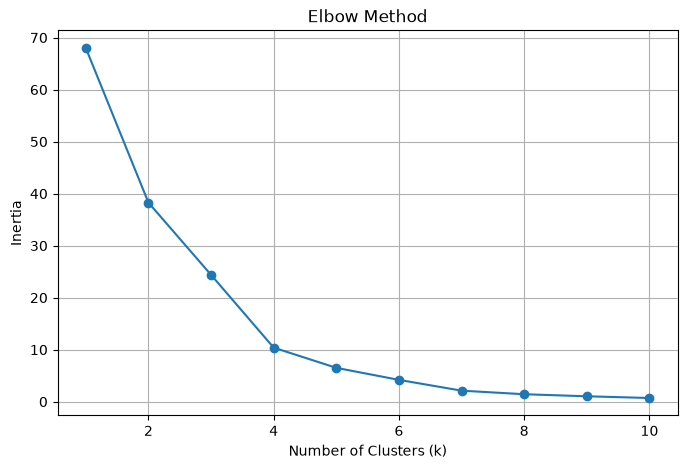

In [85]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.grid(True)
plt.savefig("charts/elbow_method.png",dpi = 300,bbox_inches = "tight")
plt.show()

### K-Means Clustering 

In [86]:
# Train K-Means 
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_features["Cluster"] = kmeans.fit_predict(scaled_features)

cluster_features

,Sub-Category,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Average_Order_Value,Cluster
0,Accessories,164186.7000,0.376381,2579.994809,217.178175,2
1,Appliances,104618.4030,0.399276,1821.621539,227.926804,1
2,Art,26705.4100,0.166056,330.488343,34.019631,1
3,Binders,200028.7850,0.218736,3848.223648,134.067550,2
4,Bookcases,113813.1987,0.238065,2220.405080,503.598224,1
5,Chairs,322822.7310,0.071358,4407.232960,531.833165,2
6,Copiers,146248.0940,0.846718,5500.774391,2215.880212,0
7,Envelopes,16128.0460,-0.027666,228.218688,65.032444,1
8,Fasteners,3001.9600,0.157034,48.742229,14.027850,1
9,Furnishings,89212.0180,0.287889,1360.017867,95.823865,1


### PCA Visualization of Product Demand Clusters

In [87]:
# Reduce to 2 dimensions
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

cluster_features["PCA1"] = pca_features[:, 0]
cluster_features["PCA2"] = pca_features[:, 1]

cluster_features.head()

,Sub-Category,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Average_Order_Value,Cluster,PCA1,PCA2
0,Accessories,164186.7000,0.376381,2579.994809,217.178175,2,0.032855,-0.128039
1,Appliances,104618.4030,0.399276,1821.621539,227.926804,1,-0.562213,0.137443
2,Art,26705.4100,0.166056,330.488343,34.019631,1,-1.728503,-0.152657
3,Binders,200028.7850,0.218736,3848.223648,134.067550,2,0.617483,-0.594676
4,Bookcases,113813.1987,0.238065,2220.405080,503.598224,1,-0.119791,-0.064887


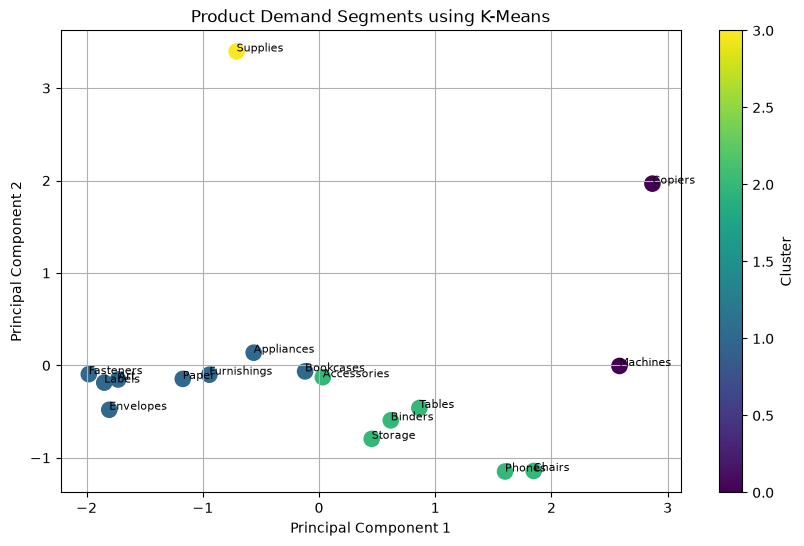

In [88]:
# scatter plot
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    cluster_features["PCA1"],
    cluster_features["PCA2"],
    c=cluster_features["Cluster"],
    cmap="viridis",
    s=120
)

# Add sub-category names
for i in range(len(cluster_features)):
    plt.text(
        cluster_features["PCA1"].iloc[i],
        cluster_features["PCA2"].iloc[i],
        cluster_features["Sub-Category"].iloc[i],
        fontsize=8
    )

plt.title("Product Demand Segments using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter, label="Cluster")

plt.grid(True)
plt.savefig("charts/product_demand_cluster.png",dpi = 300,bbox_inches = "tight")
plt.show()

In [89]:
cluster_features[["Sub-Category", "Cluster"]]

,Sub-Category,Cluster
0,Accessories,2
1,Appliances,1
2,Art,1
3,Binders,2
4,Bookcases,1
5,Chairs,2
6,Copiers,0
7,Envelopes,1
8,Fasteners,1
9,Furnishings,1


### Cluster Interpretation and Stocking Strategy 

Stocking Strategy :

| **Cluster** | **Recommended Stocking Strategy** |
| --- | --- |
| High Value Premium Products | Maintain moderate inventory levels. These products generate high revenue per sale but are purchased less frequently, so avoid overstocking while ensuring availability. |
| Low Volume, Stable Demand | Keep minimum but consistent inventory. Demand is predictable but relatively low, making these products suitable for routine replenishment. |
| High Volume, Stable Demand | Maintain high inventory levels with regular restocking. These products consistently contribute significant sales and should rarely be out of stock. |
| Rapidly Growing Demand | Closely monitor demand trends and gradually increase inventory. Since demand is growing rapidly, forecasting should be updated frequently to avoid shortages or overstocking. |

### Final Observation : 
Product demand segmentation identified four distinct demand groups. High Volume, Stable Demand products should receive inventory priority because they contribute consistently to overall sales. Premium products such as Copiers and Machines require controlled stocking due to their high value. Low Volume products should be replenished conservatively, while the rapidly growing Supplies category should be monitored closely and stocked proactively to meet increasing demand.

# Task 7 — Interactive Streamlit Dashboard

An interactive dashboard was developed using **Streamlit** to present the forecasting and business intelligence results.

### Dashboard Pages
- Sales Overview Dashboard
- Forecast Explorer
- Anomaly Report
- Product Demand Segments

The dashboard has been successfully deployed on **Streamlit Community Cloud**.

**Live Demo:**
https://sales-forecasting-dashboard-sumit.streamlit.app/

The complete implementation is provided separately in the project as:

- app.py
- pages/
- styles.css
- theme.py
- utils.py

# Task 8 — Executive Business Report

A separate executive business report has been prepared for business stakeholders, including the Head of Supply Chain and the CFO.

The report includes:

- Executive Summary
- Key EDA Findings
- Sales Forecast
- Anomaly Analysis
- Product Demand Segmentation
- Business Recommendations
- System Limitations

The report is submitted separately as:

**summary.pdf**